# HEART DISEASE PREDICTION

## OBJECTIVE
Build a system that can predict if a patient has heartdisease. 

## 1. Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)



## 2. Load Dataset

In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Users\THRISHA\OneDrive\ドキュメント\dataset.csv")
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


## 3. Dataset Overview

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (1190, 12)


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [5]:
# Statistical summary
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [6]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


In [7]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 272


## 4. Data Preprocessing

In [8]:
# Display duplicate groups including their first occurrence
duplicate_records = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
duplicate_records.head(10)

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
831,29,1,2,130,204,0,2,202,0,0.0,1,0
1019,29,1,2,130,204,0,2,202,0,0.0,1,0
755,34,0,2,118,210,0,0,192,0,0.7,1,0
1112,34,0,2,118,210,0,0,192,0,0.7,1,0
791,34,1,1,118,182,0,2,174,0,0.0,1,0
988,34,1,1,118,182,0,2,174,0,0.0,1,0
841,35,0,4,138,183,0,0,182,0,1.4,1,0
1004,35,0,4,138,183,0,0,182,0,1.4,1,0
698,35,1,4,120,198,0,0,130,1,1.6,2,1
1025,35,1,4,120,198,0,0,130,1,1.6,2,1


In [9]:
# Removing duplicate records
df.drop_duplicates(inplace=True)
print("Duplicate Rows after removal:", df.duplicated().sum())
print("Updated Dataset Shape:", df.shape)

Duplicate Rows after removal: 0
Updated Dataset Shape: (918, 12)


## 5. Exploratory Data Analysis (EDA)

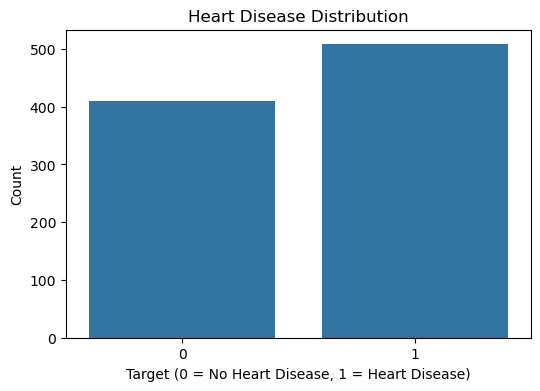

In [10]:
# Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.xlabel('Target (0 = No Heart Disease, 1 = Heart Disease)')
plt.ylabel('Count')
plt.show()

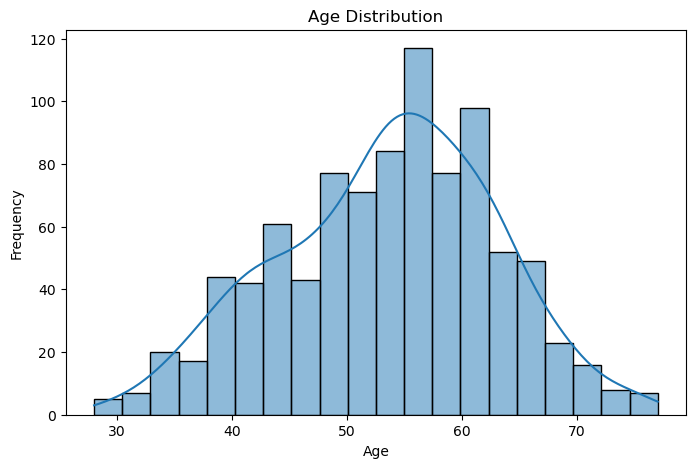

In [11]:
#visualization of Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

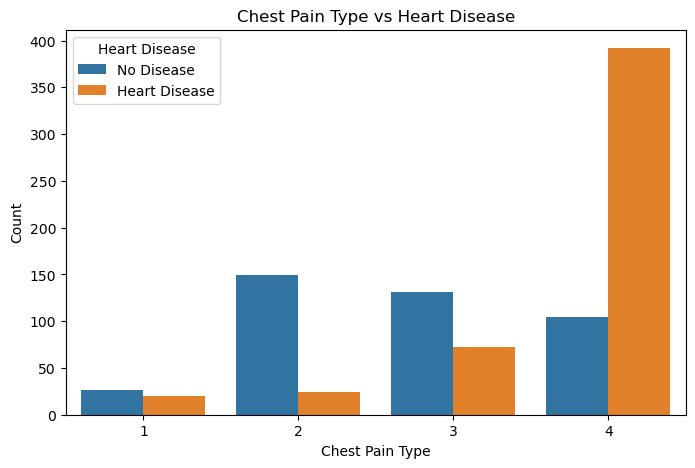

In [12]:
#Visualizing the relationship between chest pain type and heart disease status
plt.figure(figsize=(8,5))
sns.countplot(x='chest pain type', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Heart Disease',labels=['No Disease', 'Heart Disease'])
plt.show()

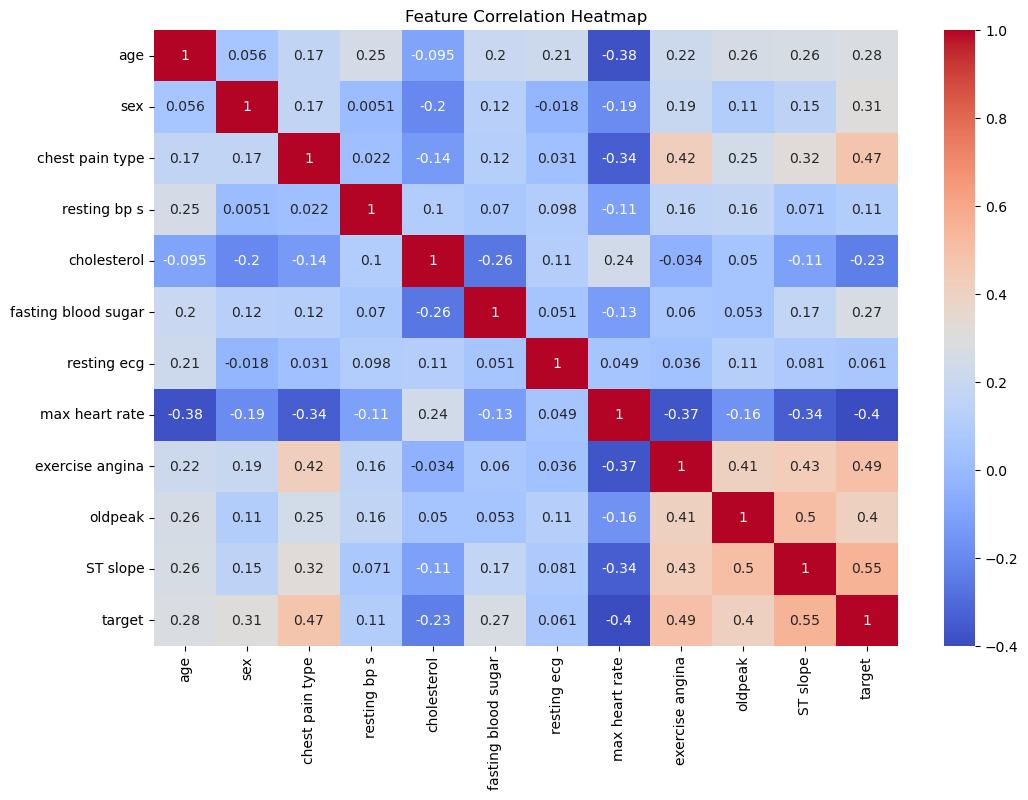

In [13]:
#visualization of correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Feature and Target Separation

In [14]:
# Separating features and target variable
X = df.drop('target', axis=1)
y = df['target']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (918, 11)
Target Shape: (918,)


## 7. Train-Test Split

In [15]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (734, 11)
Testing Set Shape: (184, 11)


## 8. Feature Scaling

In [16]:
# Standardizing feature values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## 9. Model Training and Evaluation

###  9.1 Logistic Regression

In [17]:
# Training Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Fit model on training data
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [18]:
# Making predictions on test data
lr_pred = lr_model.predict(X_test_scaled)

In [19]:
# Evaluating Logistic Regression model
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.8858695652173914
Precision: 0.8715596330275229
Recall   : 0.9313725490196079
F1 Score : 0.9004739336492891


In [20]:
# Classification report for Logistic Regression
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



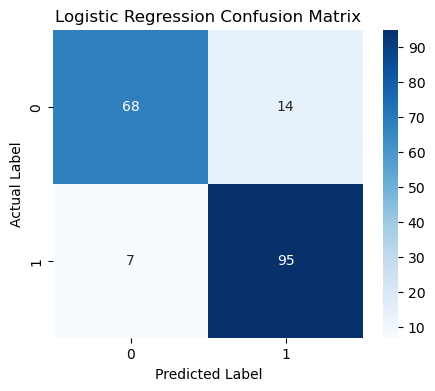

In [21]:
# Confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.2 Support Vector Classifier (SVC)

In [22]:
# Training Support Vector Classifier
svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [23]:
# Making predictions on test data
svc_pred = svc_model.predict(X_test_scaled)

In [24]:
# Evaluating SVC model
svc_accuracy = accuracy_score(y_test, svc_pred)
svc_precision = precision_score(y_test, svc_pred)
svc_recall = recall_score(y_test, svc_pred)
svc_f1 = f1_score(y_test, svc_pred)

print("Accuracy :", svc_accuracy)
print("Precision:", svc_precision)
print("Recall   :", svc_recall)
print("F1 Score :", svc_f1)

Accuracy : 0.8858695652173914
Precision: 0.8584070796460177
Recall   : 0.9509803921568627
F1 Score : 0.9023255813953488


In [25]:
# Classification report for SVC model
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           0       0.93      0.80      0.86        82
           1       0.86      0.95      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.88       184



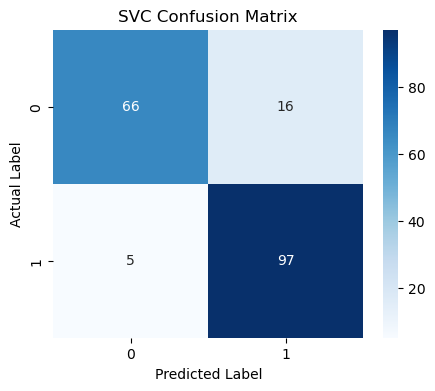

In [26]:
# Confusion matrix for SVC model
cm = confusion_matrix(y_test, svc_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.3 Random Forest

In [27]:
# Training Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
# Making predictions on test data
rf_pred = rf_model.predict(X_test)

In [29]:
# Evaluating Random Forest model
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.8858695652173914
Precision: 0.8857142857142857
Recall   : 0.9117647058823529
F1 Score : 0.8985507246376812


In [30]:
# Classification report for Random Forest model
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



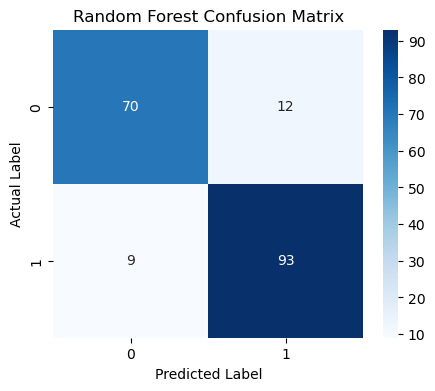

In [31]:
# Confusion matrix for Random Forest model
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 10. Model Comparison

In [32]:
# Creating model comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Classifier (SVC)', 'Random Forest'],
    'Accuracy': [lr_accuracy, svc_accuracy, rf_accuracy],
    'Precision': [lr_precision, svc_precision, rf_precision],
    'Recall': [lr_recall, svc_recall, rf_recall],
    'F1 Score': [lr_f1, svc_f1, rf_f1]})
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.88587,0.871560,0.931373,0.900474
1,Support Vector Classifier (SVC),0.88587,0.858407,0.950980,0.902326
2,Random Forest,0.88587,0.885714,0.911765,0.898551


## 11. Final Model Selection

Logistic Regression, Support Vector Classifier (SVC), and Random Forest models were trained and evaluated for heart disease prediction. Although all three models achieved comparable accuracy, SVC demonstrated the best overall performance by achieving the highest recall and F1-score while effectively minimizing false negative predictions. Since accurately identifying heart disease cases is crucial in medical applications, **the Support Vector Classifier (SVC) was selected as the final model for heart disease prediction.**

## 12. Prediction

In [33]:
# Testing model prediction using patient data
patient_data = pd.DataFrame({'age': [54],'sex': [1],'chest pain type': [3],'resting bp s': [150],'cholesterol': [195],
    'fasting blood sugar': [0],'resting ecg': [0],'max heart rate': [122],'exercise angina': [0],'oldpeak': [0.0],
    'ST slope': [1]})
patient_data_scaled = scaler.transform(patient_data)
prediction = svc_model.predict(patient_data_scaled)
if prediction[0] == 1:
    print("Predicted Class: Heart Disease Detected")
else:
    print("Predicted Class: No Heart Disease Detected")

Predicted Class: No Heart Disease Detected


In [34]:
patient_data = pd.DataFrame({'age': [45],'sex': [1],'chest pain type': [1],'resting bp s': [110],'cholesterol': [264],
    'fasting blood sugar': [0],'resting ecg': [0],'max heart rate': [132],'exercise angina': [0],'oldpeak': [1.2],
    'ST slope': [2]})
patient_data_scaled = scaler.transform(patient_data)
prediction = svc_model.predict(patient_data_scaled)
if prediction[0] == 1:
    print("Predicted Class: Heart Disease Detected")
else:
    print("Predicted Class: No Heart Disease Detected")

Predicted Class: Heart Disease Detected
